In [1]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from plotnine import *

import polars as pl
import pandas as pd
import numpy as np

df_metrics = pl.read_csv('../../data/dl-foundational/df_metrics_by_data.csv')

print(df_metrics['Model'].unique().to_list())

# Filter to key models

key_models = ['XGBoost', 'LightGBM', 'CatBoost', 'RealMLP', 'TabM', 'TabPFNv2', 'TabDPT', 'AutoGluon']

df_plot = df_metrics.filter(pl.col('Model').is_in(key_models)).with_columns(
    pl.when(pl.col("Model").is_in(['XGBoost', 'LightGBM', 'CatBoost']))
    .then(pl.lit('Boosting'))
    .otherwise(pl.lit('DL'))
    .alias('Model Group')
)


['KNN', 'TabDPT', 'XGBoost', 'TorchMLP', 'Linear', 'RF', 'TabICL', 'LightGBM', 'MNCA', 'TabM', 'EBM', 'FastAIMLP', 'TabPFNv2', 'CatBoost', 'AutoGluon', 'RealMLP', 'ExtraTrees']


## Feature Correlations

In [2]:


df_unpivot = (
    df_plot
    .unpivot(
        index=[col for col in df_plot.columns if col not in ['N', 'perc_cat', 'd']],
        on=['N', 'perc_cat', 'd'],
        variable_name='feature',
        value_name='feature_val'
    )
)

df_binned = (
    df_unpivot
    .with_columns(
        pl.when(pl.col('feature') == 'N')
        .then(pl.col('feature_val').log10().round(1))
        .when(pl.col('feature') == 'd')
        .then(pl.col('feature_val').log10().round(1))
        .otherwise(pl.col('feature_val').round(1))
        .alias('binned_val')
    )
    .group_by(['feature', 'binned_val', 'Model Group', 'Metric', 'Setting', 'Name'])
    .agg(pl.col('improvability').mean().alias('avg_improvability'))
)

facet_order = sorted(df_plot['Setting'].unique())
metric_order = ['AUC', 'logloss', 'rmse']

model_group_colors = {
    'Boosting': '#1f77b4',
    'DL': '#ff7f0e'
}

for metric_val in metric_order:
    if metric_val not in df_unpivot['Metric'].unique():
        continue

    df_metric = df_unpivot.filter(pl.col('Metric') == metric_val)
    df_binned_metric = df_binned.filter(pl.col('Metric') == metric_val)

    facet_settings = [s for s in facet_order if s in df_metric['Setting'].unique()]
    n_settings = len(facet_settings)

    for feature in ['N', 'd', 'perc_cat']:
        fig = make_subplots(
            rows=1,
            cols=n_settings,
            subplot_titles=facet_settings,
            horizontal_spacing=0.1
        )

        for i, setting in enumerate(facet_settings, 1):
            df_feature = (
                df_metric
                .filter(
                    (pl.col('Setting') == setting) &
                    (pl.col('feature') == feature)
                )
            )
            df_binned_feature = (
                df_binned_metric
                .filter(
                    (pl.col('Setting') == setting) &
                    (pl.col('feature') == feature)
                )
            )

            log_x = feature != 'perc_cat'

            model_groups = df_feature['Model Group'].unique()

            for model_group in model_groups:
            
                color = model_group_colors.get(model_group, '#888888')
            
                df_group = (
                    df_feature
                    .filter(pl.col('Model Group') == model_group)
                )
            
                df_binned_group = (
                    df_binned_feature
                    .filter(pl.col('Model Group') == model_group)
                    .sort('binned_val')
                )
            
                fig.add_trace(
                    go.Scatter(
                        x=df_group['feature_val'],
                        y=df_group['improvability'],
                        mode='markers',
                        name=model_group,
                        marker=dict(
                            size=8,
                            opacity=0.15,
                            color=color
                        ),
                        customdata=df_group[['Name', 'Model', 'Setting']].to_numpy().tolist(),
                        hovertemplate=(
                            '<b>%{customdata[0]}</b><br>'
                            'Model: %{customdata[1]}<br>'
                            'Setting: %{customdata[2]}<br>'
                            f'{feature}: ' + '%{x}<br>'
                            'Improvability: %{y:.1f}%<br>'
                            '<extra></extra>'
                        ),
                        showlegend=(i == 1),
                        legendgroup=model_group
                    ),
                    row=1,
                    col=i
                )
            
                customdata_avg = [
                    [
                        name,
                        binned_val,
                        df_feature.filter(pl.col('Name') == name)['feature_val'][0],
                        avg_improvability
                    ]
                    for name, binned_val, avg_improvability in zip(
                        df_binned_group['Name'],
                        df_binned_group['binned_val'],
                        df_binned_group['avg_improvability']
                    )
                ]
                
                fig.add_trace(
                    go.Scatter(
                        x=10 ** df_binned_group['binned_val'] if log_x else df_binned_group['binned_val'],
                        y=df_binned_group['avg_improvability'],
                        mode='markers',
                        name=None,
                        marker=dict(
                            size=14,
                            opacity=0.7,
                            symbol='diamond',
                            color=color
                        ),
                        customdata=customdata_avg,
                        hovertemplate=(
                            '<b>%{customdata[0]}</b><br>'
                            + feature + ': %{customdata[2]}<br>'
                            # + feature + ' (binned): %{customdata[1]}<br>'
                            'Avg Improvability: %{customdata[3]:.1f}%<br>'
                            '<extra></extra>'
                        ),
                        showlegend=False,
                        legendgroup=model_group
                    ),
                    row=1,
                    col=i
                )

                x_vals = df_group['feature_val'].to_numpy()
                y_vals = df_group['improvability'].to_numpy()
                # Remove NaNs and, for log_x, non-positive values
                mask = ~np.isnan(x_vals) & ~np.isnan(y_vals)
                if log_x:
                    mask = mask & (x_vals > 0)
                x_vals = x_vals[mask]
                y_vals = y_vals[mask]

                if len(x_vals) > 1:
                    if log_x:
                        x_log = np.log10(x_vals)
                        coeffs = np.polyfit(x_log, y_vals, 1)
                        x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
                        y_fit = coeffs[0] * np.log10(x_range) + coeffs[1]
                    else:
                        coeffs = np.polyfit(x_vals, y_vals, 1)
                        x_range = np.linspace(x_vals.min(), x_vals.max(), 100)
                        y_fit = coeffs[0] * x_range + coeffs[1]
                    
                    fig.add_trace(
                        go.Scatter(
                            x=x_range,
                            y=y_fit,
                            mode='lines',
                            line=dict(
                                color=color,
                                width=2,
                                dash='dash'
                            ),
                            showlegend=False,
                            legendgroup=model_group,
                            hoverinfo='skip'
                        ),
                        row=1,
                        col=i
                    )

            if feature == 'N':
                tickvals = [1e2, 1e3, 1e4, 1e5, 1e6]
                ticktext = ['100', '1k', '10k', '100k', '1M']
            elif feature == 'd':
                tickvals = [1, 10, 100, 1000]
                ticktext = ['1', '10', '100', '1k']
            else:
                tickvals = None
                ticktext = None
            fig.update_xaxes(
                title_text=feature,
                tickvals=tickvals,
                ticktext=ticktext,
                type='log' if log_x else 'linear',
                row=1,
                col=i
            )

            fig.update_yaxes(title_text='Improvability (%)', row=1, col=i, range=[0, None],)

        fig.update_layout(
            title_text=f'Improvability vs {feature} (Metric={metric_val})',
            height=500,
            template='plotly_white',
            hovermode='closest'
        )

        fig.show()

In [3]:
# correlation_results = []

# for setting in df_plot['Setting'].unique():
#     for model_group in df_plot['Model Group'].unique():

#         df_subset = (
#             df_plot
#             .filter(
#                 (pl.col('Setting') == setting)
#                 & (pl.col('Model Group') == model_group)
#             )
#         )

#         df_corr = (
#             df_subset
#             .select(['N', 'd', 'perc_cat', 'improvability'])
#             .drop_nulls()
#         )

#         if df_corr.shape[0] > 1:
#             df_ranked = (
#                 df_corr
#                 .with_columns([
#                     pl.col(col).rank('average').alias(col)
#                     for col in df_corr.columns
#                 ])
#             )
#             corr_matrix = df_ranked.corr()
#             correlation_results.append(
#                 {
#                     'Setting': setting,
#                     'Model Group': model_group,
#                     'Spearman Correlation Matrix': corr_matrix
#                 }
#             )

# correlation_results

In [4]:
# # Spearman correlation for all data (not grouped)
# df_corr_all = (
#     df_plot
#     .select(['N', 'd', 'perc_cat', 'improvability'])
#     .drop_nulls()
# )

# if df_corr_all.shape[0] > 1:
#     df_ranked_all = (
#         df_corr_all
#         .with_columns([
#             pl.col(col).rank('average').alias(col)
#             for col in df_corr_all.columns
#         ])
#     )
#     corr_matrix_all = df_ranked_all.corr()


# corr_matrix_all


In [5]:
import polars as pl
from typing import Optional, List

def compute_correlation_matrix(
    df: pl.DataFrame,
    group_by: Optional[List[str]] = None,
    method: str = 'spearman',
    decimals: int = 3,
    only_with_improvability: bool = False
) -> pl.DataFrame:
    '''
    Compute correlation matrix for selected columns, optionally grouped.
    If only_with_improvability is True, return a tidy DataFrame of correlations
    between each of ['N', 'd', 'perc_cat'] and 'improvability'.
    If False, return all group correlation matrices (or the single matrix if not grouped).

    Args:
        df: polars DataFrame containing the data.
        group_by: List of columns to group by, or None for all data.
        method: 'spearman' for rank correlation, 'pearson' for standard.
        decimals: Number of decimals to round correlations.
        only_with_improvability: If True, return only correlations with 'improvability'.

    Returns:
        polars DataFrame with group_by columns, 'feature', and 'correlation',
        or all group correlation matrices if only_with_improvability is False.
    '''
    cols = ['N', 'd', 'perc_cat', 'improvability']
    corr_rows = []
    results = []

    if group_by:

        df_groups = (
            df
            .select(group_by)
            .unique()
            .sort(group_by)
        )

        groups = df_groups.to_dicts()

        for group in groups:

            df_group = df

            for col in group_by:
                df_group = df_group.filter(pl.col(col) == group[col])

            df_corr = (
                df_group
                .select(cols)
                .drop_nulls()
            )

            if df_corr.shape[0] > 1:

                if method == 'spearman':
                    df_corr = df_corr.with_columns(
                        [pl.col(col).rank('average').alias(col) for col in cols]
                    )

                corr_matrix = (
                    df_corr
                    .corr()
                    .with_columns(pl.col(pl.Float64).round(decimals))
                )

                if only_with_improvability:
                    for feature in ['N', 'd', 'perc_cat']:
                        if (
                            feature in corr_matrix.columns
                            and 'improvability' in corr_matrix.columns
                        ):
                            idx = corr_matrix.columns.index(feature)
                            val = corr_matrix['improvability'][idx]
                        else:
                            val = None

                        group_dict = {col: group[col] for col in group_by}

                        corr_rows.append(
                            {
                                **group_dict,
                                'feature': feature,
                                'correlation': val,
                            }
                        )
                else:
                    group_dict = {col: group[col] for col in group_by}
                    group_dict['correlation_matrix'] = corr_matrix
                    results.append(group_dict)

    else:

        df_corr = (
            df
            .select(cols)
            .drop_nulls()
        )

        if df_corr.shape[0] > 1:

            if method == 'spearman':
                df_corr = df_corr.with_columns(
                    [pl.col(col).rank('average').alias(col) for col in cols]
                )

            corr_matrix = (
                df_corr
                .corr()
                .with_columns(pl.col(pl.Float64).round(decimals))
            )

            if only_with_improvability:
                for feature in ['N', 'd', 'perc_cat']:
                    if (
                        feature in corr_matrix.columns
                        and 'improvability' in corr_matrix.columns
                    ):
                        idx = corr_matrix.columns.index(feature)
                        val = corr_matrix['improvability'][idx]
                    else:
                        val = None

                    corr_rows.append(
                        {
                            'feature': feature,
                            'correlation': val,
                        }
                    )
            else:
                results.append({'correlation_matrix': corr_matrix})

    if only_with_improvability:
        return pl.DataFrame(corr_rows)

    if group_by:
        return pl.DataFrame(results)
    if results:
        return results[0]['correlation_matrix']
    return pl.DataFrame()

# By group, Spearman
improvability_corr = compute_correlation_matrix(
    df=df_plot,
    group_by=['Metric', 'Model Group', 'Setting'],
    method='pearson',
    only_with_improvability=True
    )

improvability_corr

# test.select('correlation_matrix')[0,0] # only_with_improvability=False

Metric,Model Group,Setting,feature,correlation
str,str,str,str,f64
"""AUC""","""Boosting""","""Default""","""N""",-0.266
"""AUC""","""Boosting""","""Default""","""d""",-0.171
"""AUC""","""Boosting""","""Default""","""perc_cat""",-0.009
"""AUC""","""Boosting""","""Tuned""","""N""",-0.264
"""AUC""","""Boosting""","""Tuned""","""d""",-0.15
…,…,…,…,…
"""rmse""","""DL""","""Tuned""","""d""",-0.031
"""rmse""","""DL""","""Tuned""","""perc_cat""",-0.227
"""rmse""","""DL""","""Tuned + Ens.""","""N""",0.051


/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning:

Saving 6 x 8 in image.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning:

Filename: ../../img/dl-foundational/improvability_correlation.png



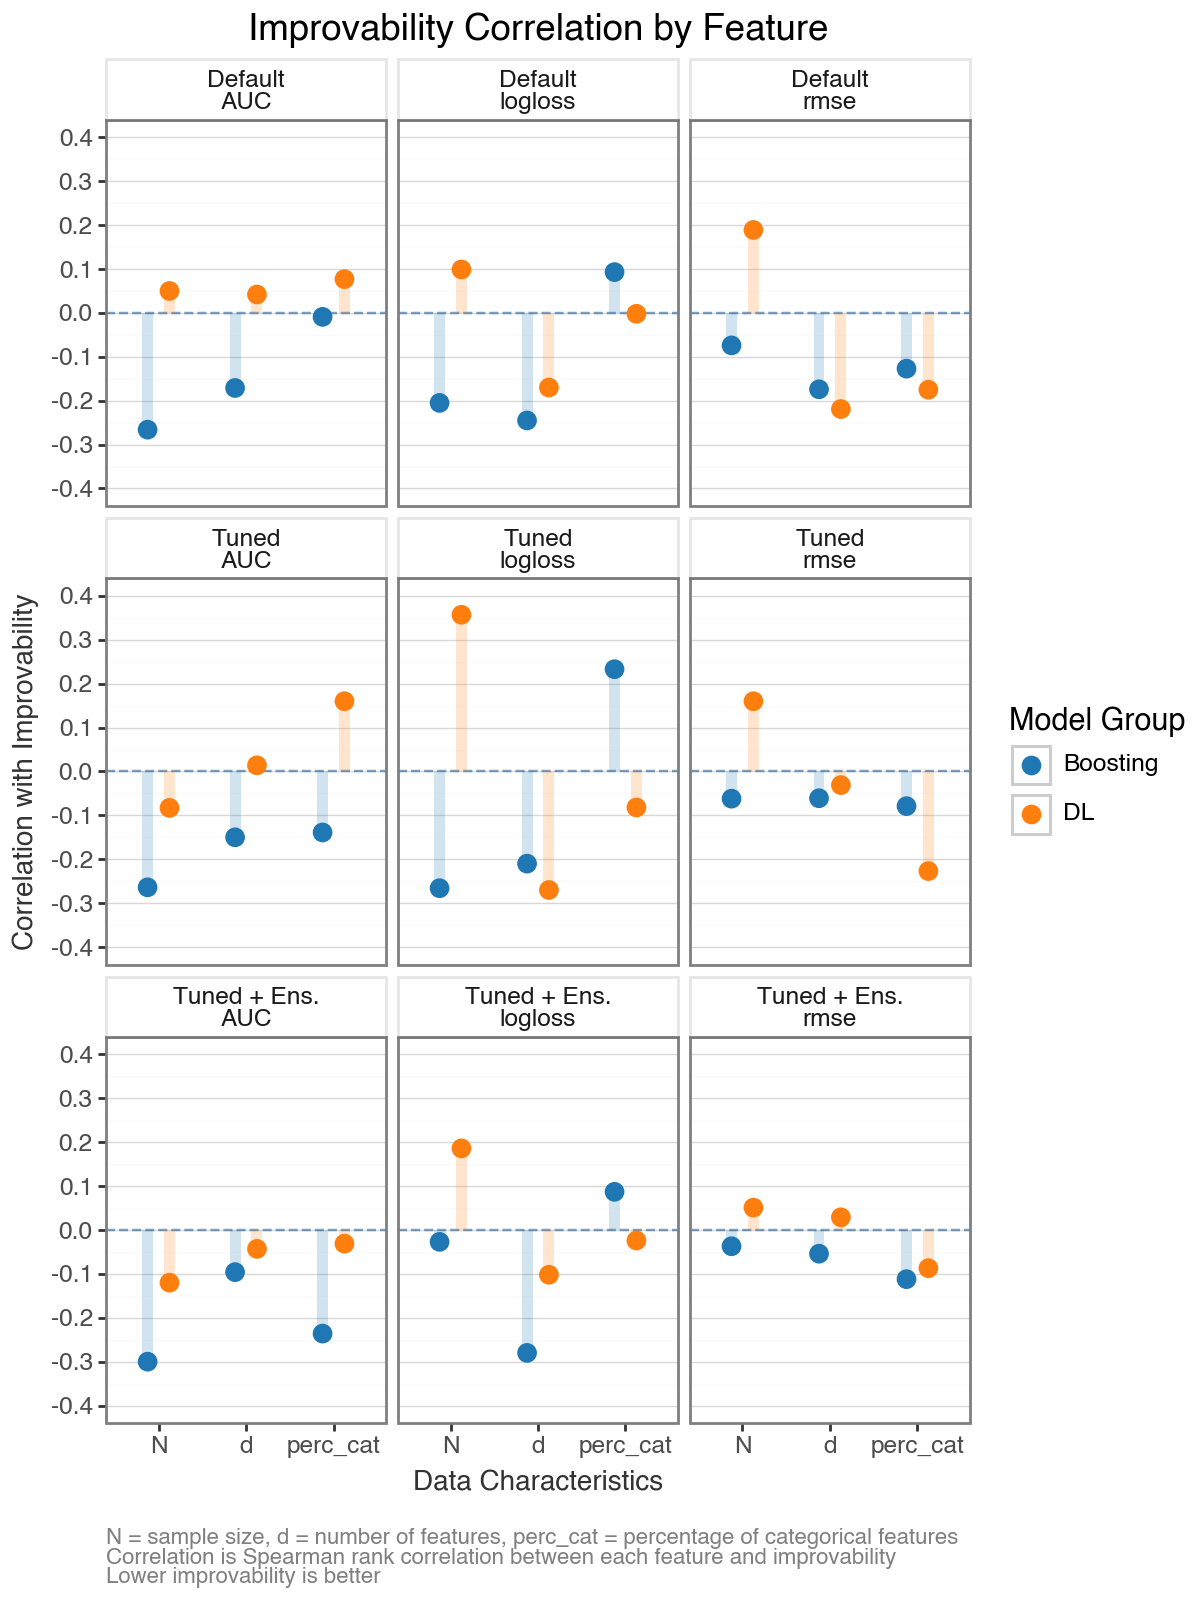

In [6]:
model_group_colors = {
    'Boosting': '#1f77b4',
    'DL': '#ff7f0e'
}

p = (
    ggplot(
        improvability_corr,
        aes(x='feature', y='correlation')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='#084887', alpha=0.5)
    + geom_col(
        aes(fill='Model Group'),
        position=position_dodge(width=0.5),  # match width to points
        width=0.25,
        alpha=0.2,
        color=None,
        show_legend=False
    )
    + geom_point(
        aes(color='Model Group'),
        position=position_dodge(width=0.5),  # match width to columns
        size=3
        )
    + scale_color_manual(values=model_group_colors)
    + scale_fill_manual(values=model_group_colors)
    + facet_wrap('~Setting + Metric', ncol=3)
    + scale_y_continuous(
        limits=(-0.4, 0.4),
        breaks=np.round(np.arange(-0.4, 0.41, 0.1), 2)
    )
    + labs(
        title='Improvability Correlation by Feature',
        caption='\nN = sample size, d = number of features, perc_cat = percentage of categorical features\nCorrelation is Spearman rank correlation between each feature and improvability\nLower improvability is better',
        x='Data Characteristics',
        y='Correlation with Improvability'
    )    
    + theme_bw()
    # + theme_minimal() # if saving
    + theme(
        axis_title=element_text(size=10, color='black', alpha=.8),
        plot_caption=element_text(size=8, color='gray', hjust=0),
        strip_background=element_rect(fill='white', color='black', alpha=.1),
        panel_grid_major_x=element_blank(),
        panel_grid_major_y=element_line(color='gray', alpha=0.3, size=0.5),
        figure_size=(6, 8),
    )

)



p.save('../../img/dl-foundational/improvability_correlation.png', dpi=300)
p.show()

In [7]:
# compute_correlation_matrix(
#     df_plot=df_plot,
#     group_by=['Setting', 'Model Group'],
#     method='spearman'
# )
# # All data, Pearson
# compute_correlation_matrix(
#     df_plot=df_plot,
#     group_by=None,
#     method='pearson'
# )
# # All data, Pearson
# compute_correlation_matrix(
#     df_plot=df_plot,
#     group_by=None,
#     method='spearman'
# )

Other stuff:
pytabkit and autogluon have both been easy to use for my testing, and pytabkit's very sklearn friendly API has been a pleasure to work with for both DL and boosting (it's just as easy either way). I haven't done much with autogluon yet, but in my toy testing it was easy to use and beat both my chosen DL and boosting model with pytabkit with the same amount of effort (but it used an ensemble of 6 models DL + boosting).

Tuned defaults for boosting from application to dozens of datasets is really nice too - very much a fire and forget baseline that will likey be hard to do much better than.

## TabArena Image Redux

Attempted to approximate/recreate the TabArena image from the paper but ChatGPT was awful at it.

In [8]:
df_tabarena = pl.read_csv('../../data/dl-foundational/tabarena_img_data.csv')

In [9]:
df_tabarena

model,train_time_s_per_1k,improvement_percent
str,i64,f64
"""XGBoost""",3,15.5
"""XGBoost""",5,14.0
"""XGBoost""",10,13.5
"""XGBoost""",20,13.2
"""XGBoost""",50,12.8
…,…,…
"""RealTabPFN-2.5""",200,5.7
"""RealTabPFN-2.5""",500,5.4
"""RealTabPFN-2.5""",1000,5.2


/var/folders/x6/4jhswqxj0sqf_gkgq6lw6l880000gn/T/ipykernel_63714/2166022708.py:30: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



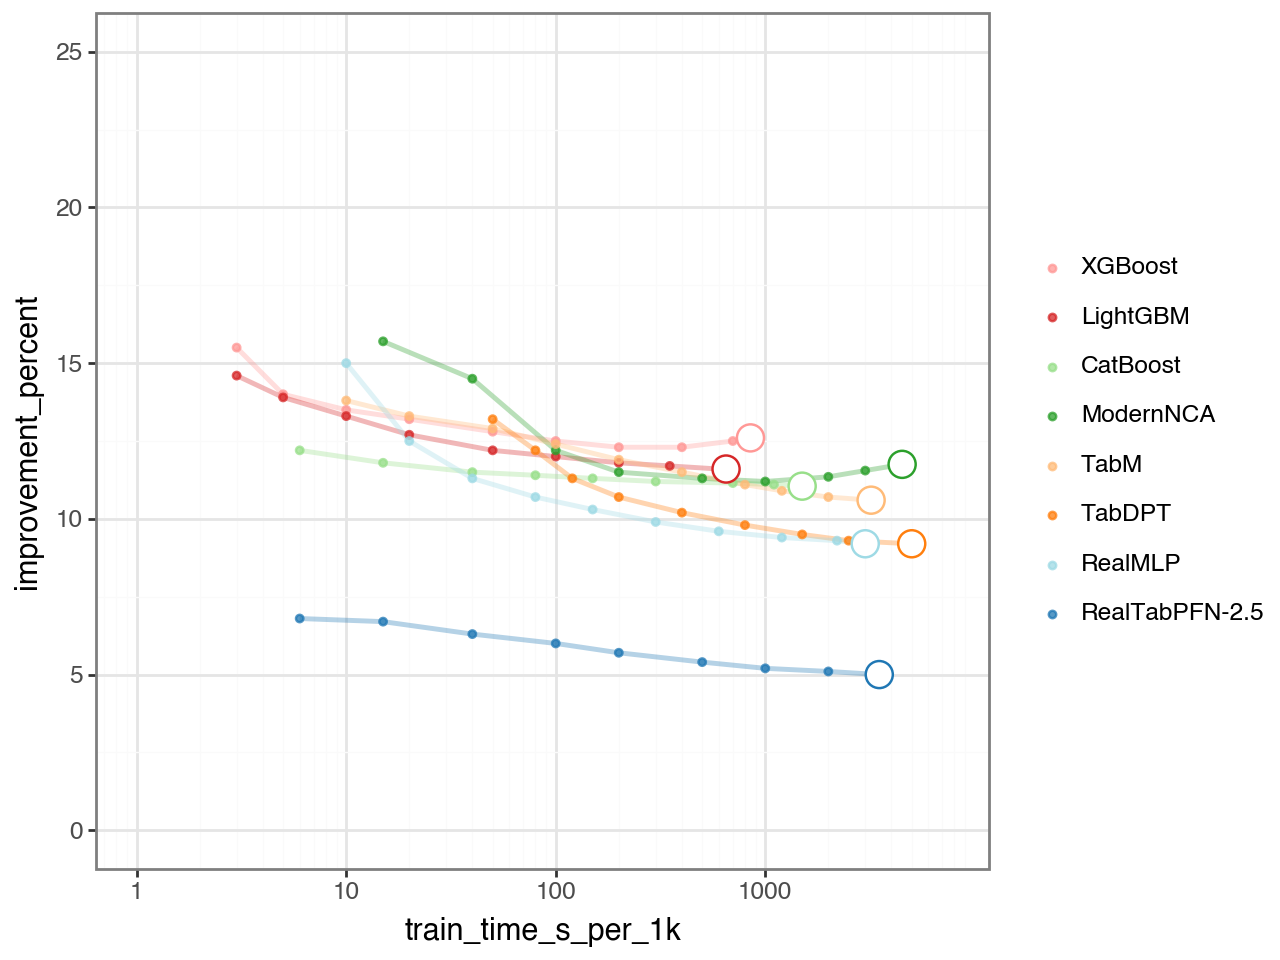

In [10]:
# Get default matplotlib color cycle
# mpl_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# # Map models to colors (repeat if more models than colors)
# model_names = df_tabarena['model'].unique().to_list()
# model_color_map = {model: mpl_colors[i % len(mpl_colors)] for i, model in enumerate(model_names)}

model_color_map = {
    "XGBoost": "#ff9896",        # light red (tab20)
    "LightGBM": "#d62728",       # red
    "CatBoost": "#98df8a",       # light green
    "ModernNCA": "#2ca02c",      # green
    "TabM": "#ffbb78",           # light orange
    "TabDPT": "#ff7f0e",         # orange
    "RealMLP": "#9edae5",        # light blue
    "RealTabPFN-2.5": "#1f77b4"  # blue
}

# Ensure model order matches color map for plotting
model_order = list(model_color_map.keys())

p_data = (
    df_tabarena.to_pandas()
    .assign(model=pd.Categorical(df_tabarena['model'], categories=model_order, ordered=True))
)

# Get the last value for each model (largest train_time_s_per_1k)
last_points = (
    p_data.sort_values('train_time_s_per_1k')
    .groupby('model', as_index=False)
    .last()
)

last_points

(
    ggplot(p_data, aes(x='train_time_s_per_1k', y='improvement_percent', color='model'))
    + geom_line(size=1, alpha=0.33, show_legend=False)
    + geom_point(size=1, alpha=.75)
    + geom_point(
        data=last_points,
        mapping=aes(x='train_time_s_per_1k', y='improvement_percent', color='model'),
        size=5,
        alpha=1,
        stroke=.5,  # border thickness
        fill='white', # border color (for filled points)
        show_legend=False  # only show legend for one set of points
    )
    + scale_color_manual(values=model_color_map)
    + scale_x_log10(limits=(1, 7500), breaks=[1, 10, 100, 1000])
    + scale_y_continuous(limits=(0, 25))
    + theme_bw()
    + theme(
        legend_key=element_blank(),
        legend_title=element_blank(),
    )
)

## Elo Rankings

In [11]:
fp = "../../data/dl-foundational/elo.csv"  # relative to repo root
df_elo = pd.read_csv(fp)

# Ensure Elo is numeric
df_elo['Elo'] = pd.to_numeric(df_elo['Elo'], errors='coerce')


In [12]:
df_elo

,Model,Elo,Elo 95% CI,Score,Rank,Harmonic Rank,Improvability (%),Median Train Time (s/1K),Median Predict Time (s/1K),Hardware
0,AutoGluon 1.4 (extreme 4h),1674,+64/-51,0.779,7.11,3.25,5.696,582.21,6.116,GPU
1,RealTabPFN-v2.5 (tuned + ensembled),1622,+87/-59,0.733,8.76,2.95,4.989,2040.22,8.920,GPU
2,RealTabPFN-v2.5 (tuned),1576,+73/-54,0.675,10.47,4.04,5.962,2040.22,1.218,GPU
3,RealTabPFN-v2.5 (default),1544,+71/-51,0.643,11.79,5.20,6.680,5.81,0.645,GPU
4,AutoGluon 1.4 (best 4h),1534,+55/-51,0.542,12.23,5.48,8.820,1735.72,2.559,CPU
5,RealMLP (tuned + ensembled),1532,+57/-47,0.541,12.29,7.13,8.942,2950.72,11.988,GPU
6,TabDPT (tuned + ensembled),1476,+64/-52,0.510,14.92,4.58,8.970,4907.64,286.652,GPU
7,TabM (tuned + ensembled),1462,+55/-42,0.415,15.58,8.43,10.369,3285.87,1.472,GPU
8,LightGBM (tuned + ensembled),1446,+36/-31,0.372,16.40,11.34,11.570,416.98,2.639,CPU
9,RealMLP (tuned),1442,+47/-47,0.371,16.62,8.87,10.411,2950.72,0.663,GPU


/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning:

geom_bar : Removed 21 rows containing missing values.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning:

Cannot generate legend for the 'alpha' aesthetic. Make sure you have mapped a variable to it



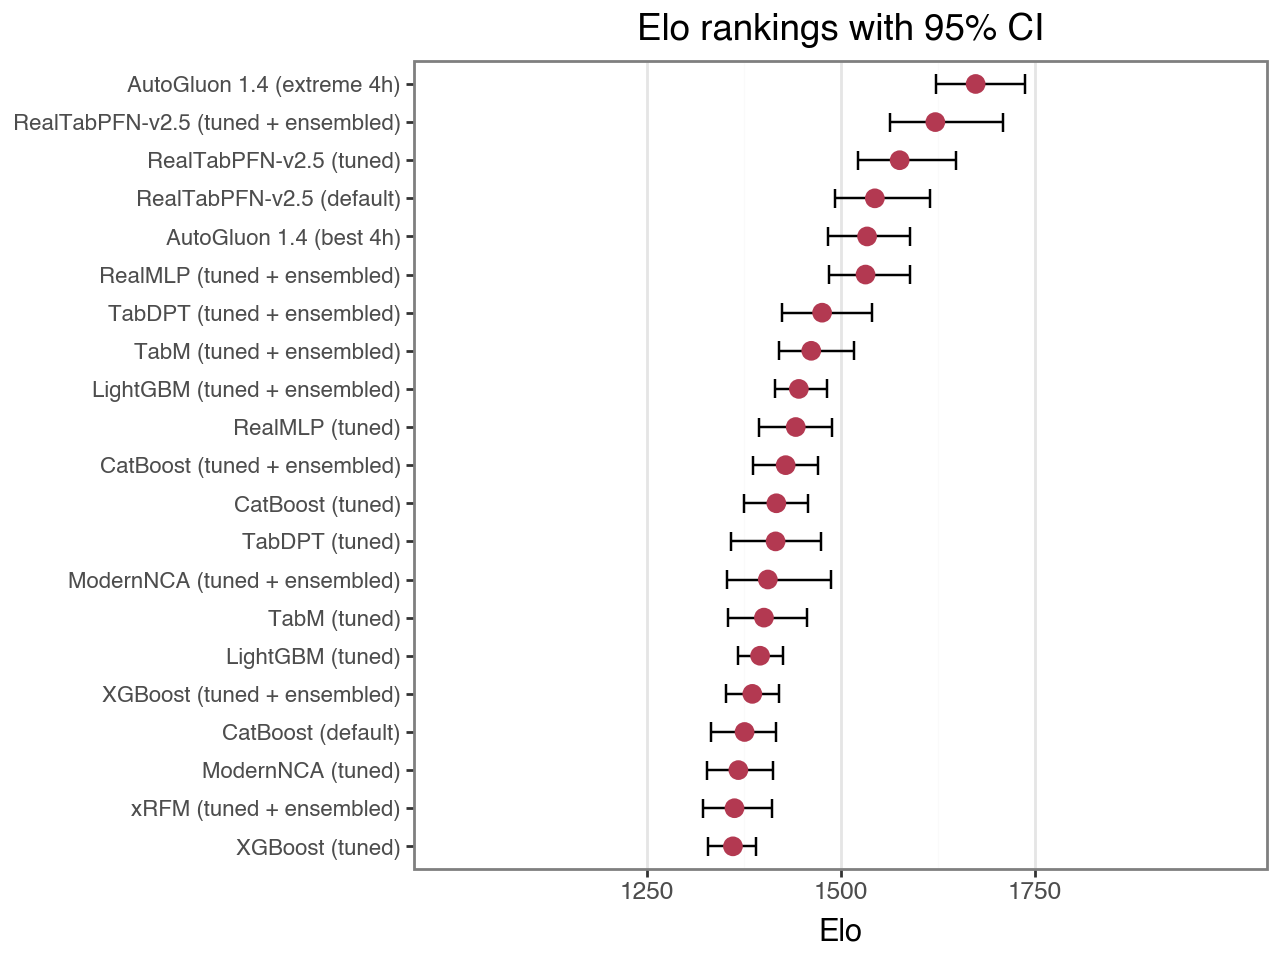

In [13]:
# Parse "Elo 95% CI" strings like "+39/-39" into numeric bounds
ci = df_elo['Elo 95% CI'].astype(str).str.strip()
ci_parts = ci.str.split('/', expand=True)
ci_up = ci_parts[0].str.replace('+', '').str.replace(' ', '').astype(int)
ci_dn = ci_parts[1].str.replace('-', '').str.replace(' ', '').astype(int)

df_elo['Elo_low'] = df_elo['Elo'] - ci_dn
df_elo['Elo_high'] = df_elo['Elo'] + ci_up

# Order by Elo descending for plotting
df_elo = df_elo.sort_values('Elo', ascending=True)  # ascending=True because we'll flip coordinates
df_elo['Model'] = pd.Categorical(df_elo['Model'], categories=df_elo['Model'], ordered=True)

# Build plotnine plot: geom_col (bar), geom_errorbar (CI) and geom_point (lollipop head)
p = (
    ggplot(df_elo, aes(x='Model', y='Elo'))
    + geom_bar(fill='#084887', width=0.25, alpha=0.75, stat='identity')
    + geom_errorbar(aes(ymin='Elo_low', ymax='Elo_high'), width=0.5, color='black')
    + geom_point(
        # aes(alpha = 'Median Train Time (s/1K)'),
        color='#b33951',
        size= 3
    )
    # + coord_cartesian(ylim=(1000, 1800))
    + coord_flip()
    + guides(size=guide_legend(title='Median Train Time (s/1K)'))
    + labs(x='', y='Elo', title='Elo rankings with 95% CI')
    # + scale_size_continuous(trans='log10', breaks=[1, 10, 100, 1000, 5000], labels=['1', '10', '100', '1000', '5000'])
    + scale_alpha_continuous(range=(1, .1), breaks=[4000, 2000,1000, 100, 10, 1], )
    + scale_y_continuous(breaks=[0, 1250, 1500, 1750], limits=(1000, 2000))
    + theme_minimal()
    + theme_bw()
    + theme(
        panel_grid_major_y=element_blank(),
        axis_text_y=element_text(size=8),
        legend_key=element_blank(),
        legend_title=element_text(size=6, weight='bold'),
    )
)

p.show()

## Elo/Improvability vs. Inference Time

In [14]:
import re

# Select models matching Boost, TabM, Real, Gluon, DPT followed by 'tuned + ensemb'
pattern = re.compile(
    r"(XGBoost|LightGBM|CatBoost|RealMLP|TabM|TabDPT|PFN|AutoGluon).*(tuned \+ ensemb)", re.IGNORECASE
)
pdat_te = df_elo[df_elo['Model'].str.contains(pattern)].assign(Model=lambda x: x['Model'].str.replace('(tuned + ensembled)', '(T+E)', regex=False))

pattern = re.compile(
    r"(XGBoost|LightGBM|CatBoost|RealMLP|TabM|TabDPT|PFN|AutoGluon).*(tuned\)$)", re.IGNORECASE
)

pdat_tuned = df_elo[df_elo['Model'].str.contains(pattern)].assign(Model=lambda x: x['Model'].str.replace(r' \(tuned\)$', ' (T)', regex=True))

# (
#     ggplot(pdat_te, aes(x='Median Predict Time (s/1K)', y='Elo', label='Model'))
#     + geom_point(size=3, color='#084887', alpha=0.7)
#     + geom_point(
#         data=pdat_tuned,
#         mapping=aes(x='Median Predict Time (s/1K)', y='Elo'),
#         size=4,
#         color='#b33951',
#         alpha=0.9,
#         show_legend=False
#     )
#     + geom_text(nudge_y=15, color='#084887', size=7, ha='left', va='bottom', alpha=0.7)
#     + geom_text(
#         data=pdat_tuned,
#         mapping=aes(x='Median Predict Time (s/1K)', y='Elo', label='Model'),
#         nudge_y=-15,
#         size=7,
#         ha='left',
#         va='top',
#         alpha=0.9,
#         color='#b33951',
#         show_legend=False
#     )
#     + scale_x_log10()
#     + labs(
#         x='Median Predict Time (s/1K) [log scale]',
#         y='Elo',
#         title='Elo vs. Median Inference Time for Selected Models'
#     )
#     + theme_bw()
#     + theme(
#         axis_text_x=element_text(size=8),
#         axis_text_y=element_text(size=8),
#         plot_title=element_text(size=10, weight='bold'),
#         figure_size=(6, 4)
#     )
# )


/var/folders/x6/4jhswqxj0sqf_gkgq6lw6l880000gn/T/ipykernel_63714/2442510732.py:7: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.

/var/folders/x6/4jhswqxj0sqf_gkgq6lw6l880000gn/T/ipykernel_63714/2442510732.py:13: UserWarning:

This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.



In [15]:
def plot_tuned_vs_ensemble_inference(
    target_col: str = "Elo",
    time_col: str = "Median Predict Time (s/1K)",
    model_label: str = "Model",
    base_theme=theme_bw,
    title: str = None,
    ylab: str = None,
    nudge_y_tuned: float = -10,
    nudge_y_te: float = 10,
    arrow_position: str = None
):
    """
    Plot tuned vs. tuned+ensemble for a given target metric with optional arrow annotation.

    Parameters:
    - target_col: Column name for the target metric.
    - time_col: Column name for the time metric.
    - model_label: Column name for the model labels.
    - base_theme: Base theme for the plot.
    - title: Title of the plot.
    - ylab: Label for the y-axis.
    - nudge_y_tuned: Vertical nudge for tuned model labels.
    - nudge_y_te: Vertical nudge for tuned+ensemble model labels.
    - arrow_position: Optional; position of the arrow annotation. Accepts 'bl' (bottom-left),
      'tl' (top-left), or 'tr' (top-right). Default is None.
    """
    # Extract base model names for matching
    pdat_tuned_base = (
        pdat_tuned
        .assign(base_model=lambda x: x[model_label].str.split('(').str[0])
    )
    pdat_te_base = (
        pdat_te
        .assign(base_model=lambda x: x[model_label].str.split('(').str[0])
    )

    # Merge to create line segments
    pdat_lines = pdat_tuned_base.merge(
        pdat_te_base[["base_model", time_col, target_col]],
        on="base_model",
        suffixes=("_tuned", "_te")
    )

    pdat_lines = pdat_lines.assign(
        model_group=lambda x: np.where(
            x["base_model"].str.contains("boost|gbm", case=False),
            "Boosting",
            "DL"
        )
    )

    if not title:
        title = f"{target_col} vs. Median Inference Time for Selected Models"
    if not ylab:
        ylab = target_col

    segment_mapping = aes(
        x=f"{time_col}_tuned",
        y=f"{target_col}_tuned",
        xend=f"{time_col}_te",
        yend=f"{target_col}_te",
        linetype="model_group"
    )

    p = (
        ggplot(pdat_te, aes(x=time_col, y=target_col, label=model_label))
        + geom_segment(
            data=pdat_lines,
            mapping=segment_mapping,
            color="gray",
            alpha=0.4,
            size=.75,
            show_legend=False
        )
        + geom_point(size=3, color="#084887", alpha=0.7)
        + geom_point(
            data=pdat_tuned,
            mapping=aes(x=time_col, y=target_col),
            size=4,
            color="#b33951",
            alpha=0.9,
            show_legend=False
        )
        + geom_text(
            nudge_y=nudge_y_te,
            color="#084887",
            size=5,
            ha="left",
            va="top",
            alpha=0.7
        )
        + geom_text(
            data=pdat_tuned,
            mapping=aes(x=time_col, y=target_col, label=model_label),
            nudge_y=nudge_y_tuned,
            size=5,
            ha="left",
            va="bottom",
            alpha=0.9,
            color="#b33951",
            show_legend=False
        )
        + scale_linetype_manual(values={"Boosting": "dashed", "DL": "dotted"})
        + scale_x_log10()
        + labs(
            x=f"{time_col} [log scale]",
            y=ylab,
            title=title,
            caption="\nLines connect tuned (T) to tuned + ensembled (T+E) versions of the same base model\nDashed lines indicate boosting models, dotted lines indicate deep learning models"
        )
        + base_theme()
        + theme(
            axis_text_x=element_text(size=8),
            axis_text_y=element_text(size=8),
            axis_title_y=element_text(angle=0, vjust=1),
            plot_title=element_text(size=10, weight="bold"),
            plot_caption=element_text(size=8, color="gray", hjust=0),
            figure_size=(8, 6)
        )
    )

    # Add arrow annotation if specified
    if arrow_position:
        # Determine axis limits from the data
        x_min = min(pdat_tuned[time_col].min(), pdat_tuned[time_col].min())
        x_max = max(pdat_tuned[time_col].max(), pdat_tuned[time_col].max())
        y_min = min(pdat_tuned[target_col].min(), pdat_tuned[target_col].min())
        y_max = max(pdat_tuned[target_col].max(), pdat_tuned[target_col].max())

        # Padding for aesthetics
        x_pad = (x_max - x_min) * 0.05
        y_pad = (y_max - y_min) * 0.05

        if arrow_position == "bl":
            # bottom left: arrow from near bottom left toward inside
            p += geom_segment(
                aes(
                    x=.25,
                    xend=0.05,
                    y=y_min*.975,
                    yend=y_min *.95
                ),
                arrow=arrow(type="closed", ends="last", length=0.1),
                color="black"
            )
        elif arrow_position == "tl":
            # top left: arrow from near top left toward inside
            p += geom_segment(
                aes(
                    x=.25,
                    xend=0.05,
                    y=y_max*1.05,
                    yend=y_max *1.1
                ),
                arrow=arrow(type="closed", ends="last", length=0.1),
                color="black"
            )
        elif arrow_position == "tr":
            # top right: arrow from near top right toward inside
            p += geom_segment(
                aes(
                    x=x_max - x_pad,
                    y=y_max - y_pad,
                    xend=x_max - x_pad * 4,
                    yend=y_max - y_pad * 4
                ),
                arrow=arrow(type="closed", ends="last", length=0.1),
                color="black"
            )
        elif arrow_position == "tl":
            p += geom_segment(
                aes(x=0.1, y=0.9, xend=0.3, yend=0.7),
                arrow=arrow(type="closed", ends="last", length=0.1),
                color="black"
            )
        elif arrow_position == "tr":
            p += geom_segment(
                aes(x=0.9, y=0.9, xend=0.7, yend=0.7),
                arrow=arrow(type="closed", ends="last", length=0.1),
                color="black"
            )

    return p

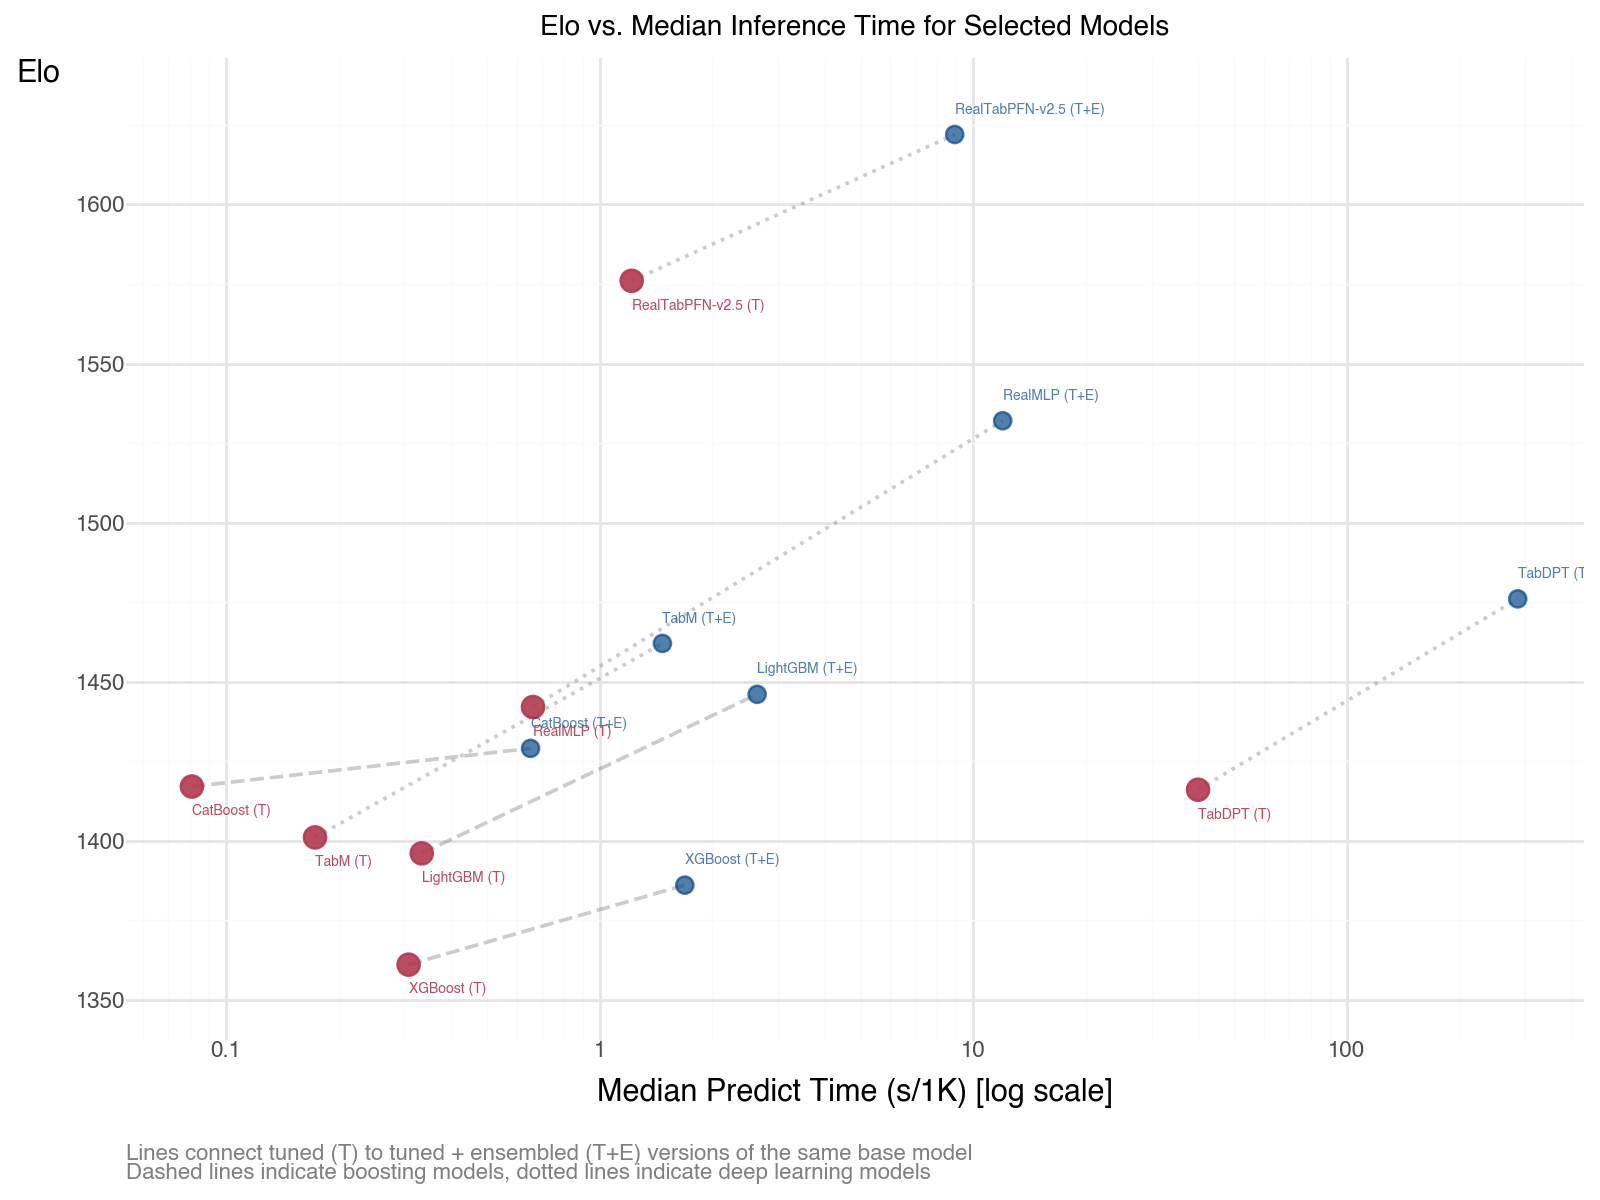

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning:

Saving 6.4 x 4.8 in image.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning:

Filename: ../../img/dl-foundational/elo_vs_inference_time.png

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning:

geom_bar : Removed 21 rows containing missing values.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning:

Cannot generate legend for the 'alpha' aesthetic. Make sure you have mapped a variable to it



In [16]:
p_elo = plot_tuned_vs_ensemble_inference(
    target_col="Elo",
    base_theme=theme_minimal
)
p_elo.show()
p.save('../../img/dl-foundational/elo_vs_inference_time.png', dpi=300)


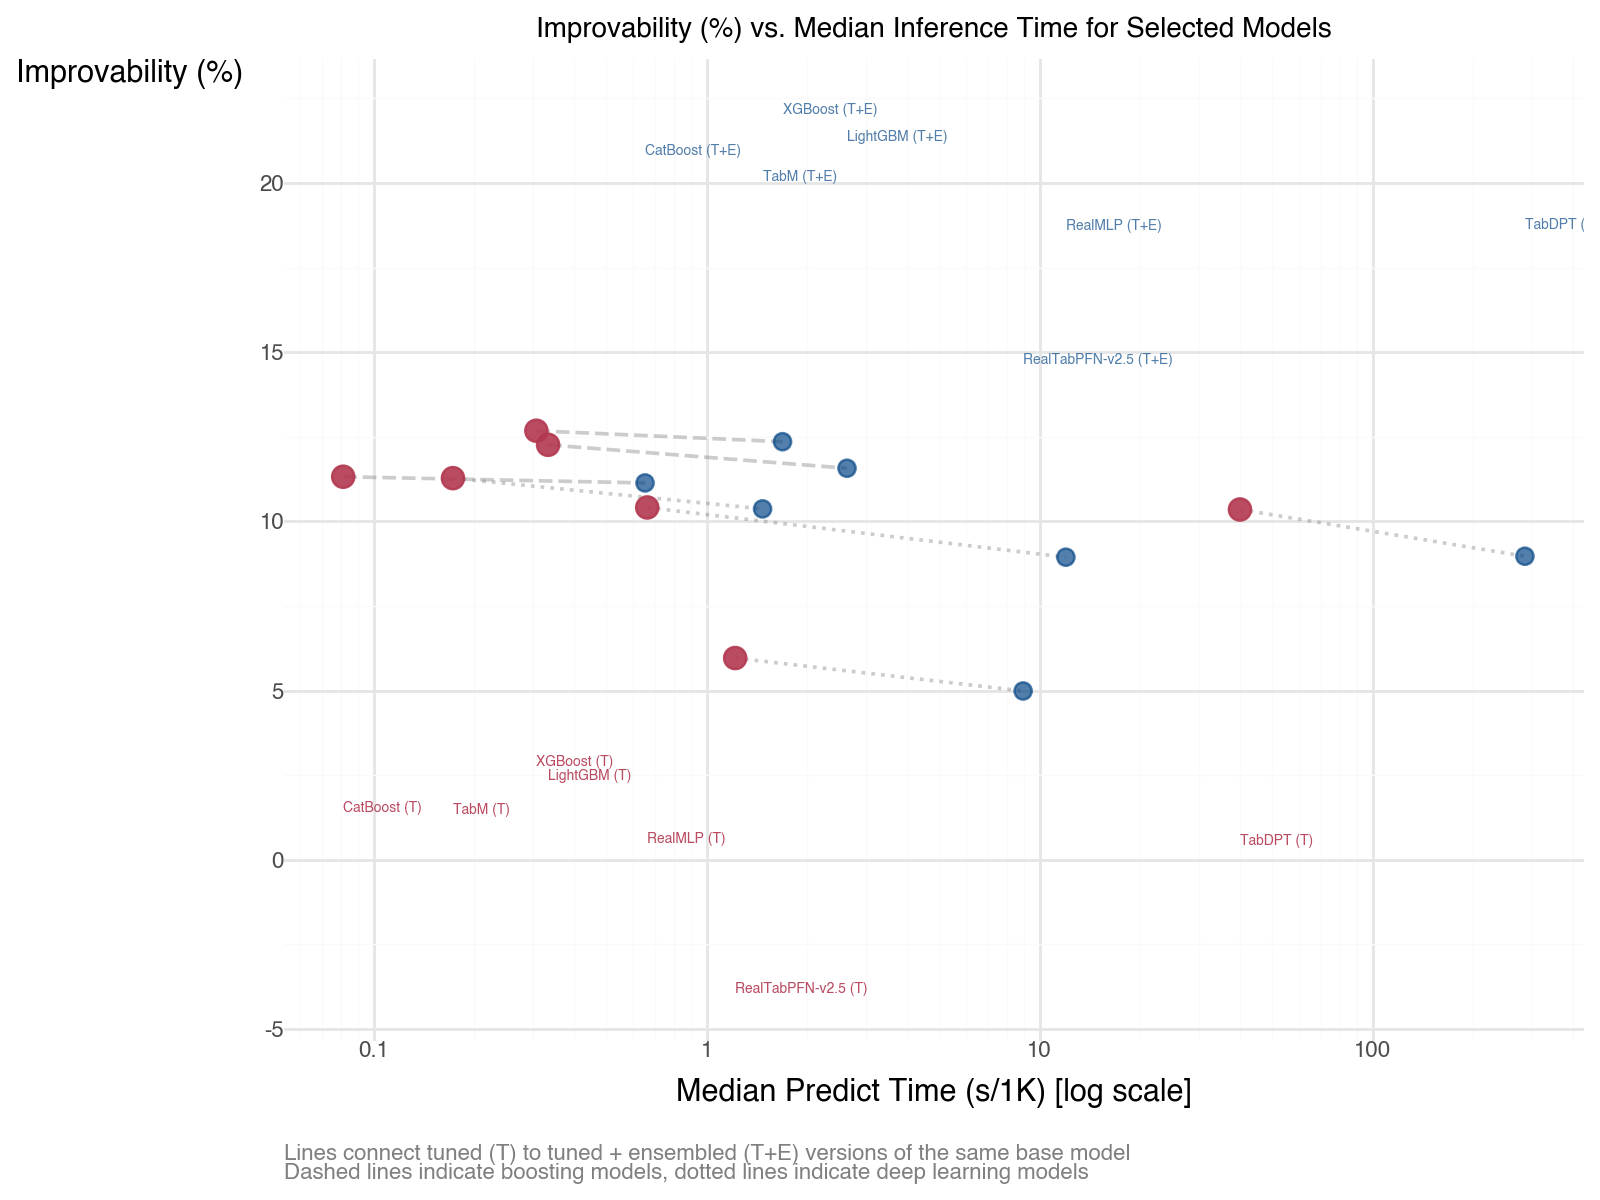

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning:

Saving 6.4 x 4.8 in image.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning:

Filename: ../../img/dl-foundational/elo_vs_inference_time.png

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/layer.py:364: PlotnineWarning:

geom_bar : Removed 21 rows containing missing values.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning:

Cannot generate legend for the 'alpha' aesthetic. Make sure you have mapped a variable to it



In [17]:
p_elo = plot_tuned_vs_ensemble_inference(
    target_col="Improvability (%)",
    base_theme=theme_minimal
)
p_elo.show()
p.save('../../img/dl-foundational/elo_vs_inference_time.png', dpi=300)


## Target Type Breakdown

In [18]:
df_metrics = df_metrics.with_columns(
    pl.when(pl.col('Metric') == 'AUC').then(pl.lit('Binary'))
    .when(pl.col('Metric') == 'logloss').then(pl.lit('Multiclass'))
    .when(pl.col('Metric') == 'rmse').then(pl.lit('Regression'))
    .otherwise(pl.lit('Unknown'))                                          
    .alias('target_type')
)

In [19]:
df_metrics.columns

['Dataset_Task_ID',
 'Name',
 'Ref',
 'N',
 'd',
 'C',
 'perc_cat',
 'Subset',
 'Metric',
 'Setting',
 'Model',
 'Score',
 'BestScore',
 'improvability',
 'target_type']

In [20]:
(
    df_metrics
    .with_columns(
        pl.when(pl.col('Metric').is_in(['AUC']))
        .then(pl.col('Score').rank().over(['Name', 'Setting']))
        .when(pl.col('Metric').is_in(['logloss', 'rmse']))
        .then(pl.col('Score').rank(descending=True).over(['Name', 'Setting']))
        .alias('rank')
    )
    .select(['Name', 'Model', 'Score', 'rank'])
    .sort(['Name', 'Model', 'Score'])
)


Name,Model,Score,rank
str,str,f64,f64
"""APSFailure""","""AutoGluon""",null,null
"""APSFailure""","""AutoGluon""",null,null
"""APSFailure""","""AutoGluon""",0.993,13.0
"""APSFailure""","""CatBoost""",0.992,12.5
"""APSFailure""","""CatBoost""",0.992,9.0
…,…,…,…
"""wine_quality""","""TorchMLP""",0.653,4.0
"""wine_quality""","""TorchMLP""",0.691,3.0
"""wine_quality""","""XGBoost""",0.61,8.5


In [21]:
df_target_type = (
    df_metrics
    .with_columns(
        pl.when(pl.col('Metric').is_in(['AUC']))
        .then(pl.col('Score').rank(descending=True).over(['Name', 'Setting']))
        .when(pl.col('Metric').is_in(['logloss', 'rmse']))
        .then(pl.col('Score').rank().over(['Name', 'Setting']))
        .alias('rank')
    )
    .filter(pl.col('Model').is_in(key_models))
    .group_by(['target_type', 'Model', 'Setting'])
    .agg(
        mean_rank=pl.col('rank').mean(),
        harmonic_rank=(pl.col('rank').count() / pl.col('rank').map_elements(lambda x: 1.0 / x).sum()),
        mean_improvability=pl.col('improvability').mean(),
    )
    .sort(['target_type', 'mean_improvability'])
)

/var/folders/x6/4jhswqxj0sqf_gkgq6lw6l880000gn/T/ipykernel_63714/4225067840.py:14: PolarsInefficientMapWarning:


Expr.map_elements is significantly slower than the native expressions API.
Only use if you absolutely CANNOT implement your logic otherwise.
Replace this expression...
  - pl.col("rank").map_elements(lambda x: ...)
with this one instead:
  + 1.0 / pl.col("rank")




/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:615: PlotnineWarning:

Saving 6 x 8 in image.

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/ggplot.py:616: PlotnineWarning:

Filename: ../../img/dl-foundational/model_performance_by_target_type.png

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning:

Cannot generate legend for the 'linetype' aesthetic. Make sure you have mapped a variable to it

/Users/micl/anaconda3/envs/m-clark-github-io/lib/python3.12/site-packages/plotnine/guides/guides.py:211: PlotnineWarning:

Cannot generate legend for the 'linetype' aesthetic. Make sure you have mapped a variable to it



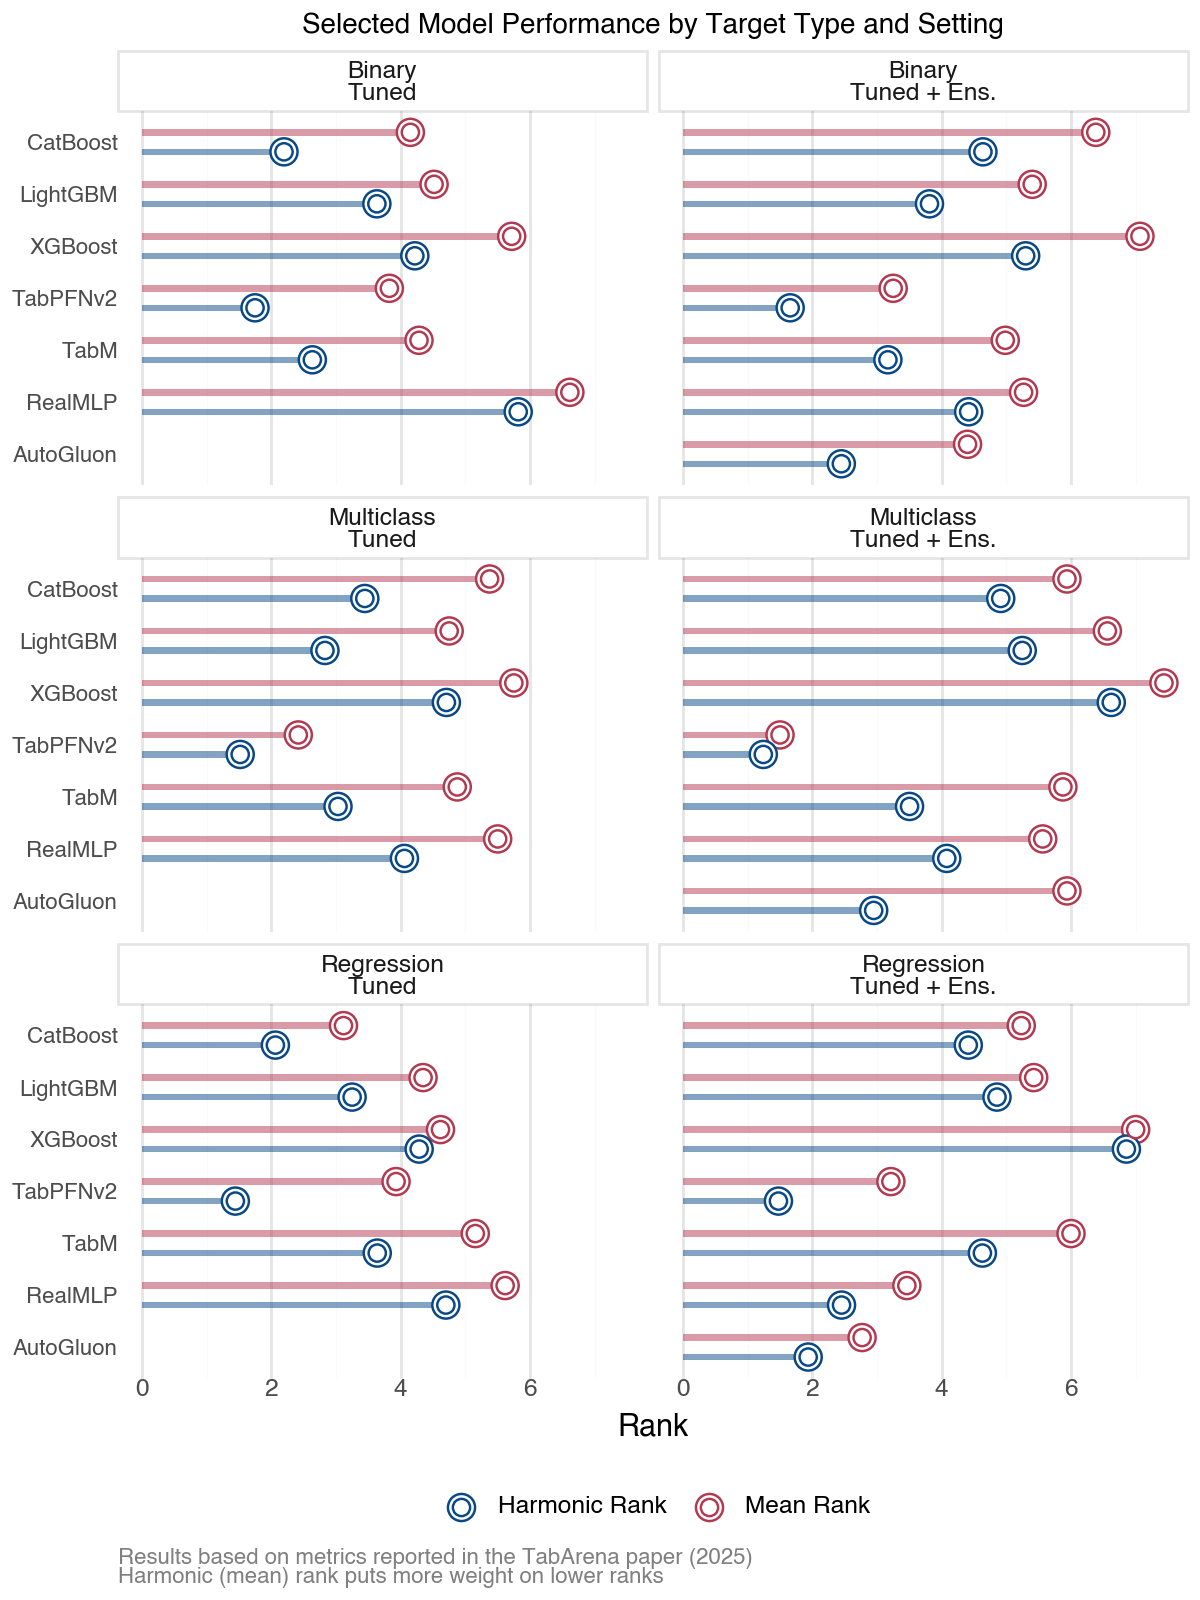

In [142]:
mod_order = df_target_type.group_by('Model').agg(pl.col('mean_rank').mean()).sort('mean_rank', descending=True).get_column('Model')

df_lollipop = (
    df_target_type
    .drop_nulls()
    .filter(pl.col('Setting').ne('Default'))
    .with_columns(
        pl.col('Model').cast(pl.Enum(mod_order))
    )
)

df_lollipop_long = (
    df_lollipop
    .unpivot(
        index=['target_type', 'Model', 'Setting', 'mean_improvability'],
        on=['mean_rank', 'harmonic_rank'],
        variable_name='rank_type',
        value_name='rank_value'
    )
    .with_columns(
        pl.when(pl.col("Model").is_in(['XGBoost', 'LightGBM', 'CatBoost']))
        .then(pl.lit('Boosting'))
        .otherwise(pl.lit('DL'))
        .alias('Model Group')
    )
)

df_lollipop_long = (
    df_lollipop_long.with_columns(
        pl.col('Model Group').cast(pl.Enum(['Boosting', 'DL'])),
    )
)
df_lollipop_long = df_lollipop_long.sort(['target_type', 'Setting', 'Model Group', 'rank_value'])

# extract unique Model values preserving their existing order (first occurrence)
models = df_lollipop_long.get_column('Model').to_list()
unique_models = list(dict.fromkeys(models))
unique_models.reverse()  # reverse to match the order in the plot (descending rank)
df_lollipop_long = df_lollipop_long.with_columns(
    pl.col('Model').cast(pl.Enum(unique_models))
)


p_lollipop = (
    ggplot(df_lollipop_long, aes(x='Model', y='rank_value', fill='rank_type'))
    + geom_col(
        aes(
            # linetype='rank_type',
            # color='Model Group'
        ),
        position=position_dodge(width=0.75),
        width=0.25,
        alpha=0.5,
        show_legend=False
    )
    + geom_point(
        aes(color='rank_type', border='Model Group'),
        position=position_dodge(width=0.75),
        fill='white',
        size=5,
        show_legend=True,
        shape='o',
        stroke=0.5
    )
    + geom_point(
        aes(color='rank_type', border='Model Group'),
        position=position_dodge(width=0.75),
        fill='white',
        size=3,
        show_legend=True,
        shape='o',
        stroke=0.5
    )
    + scale_linetype_manual(values={'mean_rank': 'dashed', 'harmonic_rank': 'dotted'})
    + scale_color_manual(
        values={'mean_rank': '#b33951', 'harmonic_rank': '#084887'},
        labels={'mean_rank': 'Mean Rank', 'harmonic_rank': 'Harmonic Rank'},
        aesthetics= ['color', 'fill']
    )
    + coord_flip()
    + facet_wrap('~target_type+Setting', ncol=2)
    + labs(
        x='',
        y='Rank',
        title='Selected Model Performance by Target Type and Setting',
        caption='Results based on metrics reported in the TabArena paper (2025)\nHarmonic (mean) rank puts more weight on lower ranks'
    )
    + theme_bw()
    + theme_minimal() # if saving
    + theme(
        axis_text_y=element_text(size=8),
        panel_grid_major_y=element_blank(),
        strip_background=element_rect(fill='white', color='black', alpha=.1),
        plot_title=element_text(size=10, weight='bold'),
        plot_caption=element_text(size=8, color='gray', hjust=0),
        legend_key=element_blank(),
        legend_title=element_blank(),
        legend_position='bottom',
        figure_size=(6, 8),
    )
)

p_lollipop.save('../../img/dl-foundational/model_performance_by_target_type.png', dpi=300)
p_lollipop.show()